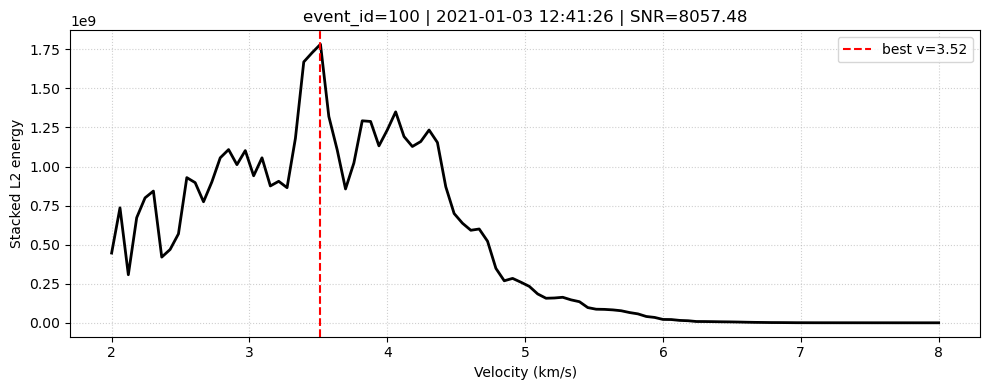

{'event_id': 100,
 'snr': 8057.480440585899,
 'best_v_km_s': 3.515151515151515,
 'num_stations': 6,
 'files_used': ['2021-01-03T00-00-00.mseed',
  '2021-01-03T08-00-00.mseed',
  '2021-01-03T16-00-00.mseed']}

In [4]:
# ============================================================
# Robust + Efficient 1D velocity QC (quiet version)
# ============================================================

from pathlib import Path
from typing import Dict, Tuple, Optional, List
import re
from datetime import datetime
from bisect import bisect_right

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import obspy
from obspy import read, UTCDateTime
from obspy.geodetics.base import gps2dist_azimuth


# ----------------------------
# Paths
# ----------------------------
DATA_BASE = Path("/home/elizabeth/work/research/pavlof/data")
CATALOG_CSV = Path("/home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_hypodd_catalog.csv")
PICKS_CLEAN_CSV = Path("/home/elizabeth/soft/src/QuickQuake/data/merged/input/GAMMA_picks_cleaned.csv")
STATIONS_JSON = Path("/home/elizabeth/soft/src/QuickQuake/data/merged/input/GAMMA_station_list.json")


# ----------------------------
# Load inputs
# ----------------------------
def load_inputs():
    catalog = pd.read_csv(CATALOG_CSV)
    picks   = pd.read_csv(PICKS_CLEAN_CSV)

    catalog["time"] = pd.to_datetime(catalog["time"], utc=True, errors="coerce")
    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")

    station_df = pd.read_json(STATIONS_JSON).T
    station_df.index.name = "id"
    station_df["id"] = station_df.index.astype(str)
    station_df["elev_km"] = station_df.get("elevation(m)", 0.0).astype(float) / 1000.0

    stations = (
        station_df.rename(columns={"latitude": "lat", "longitude": "lon"})
        .reset_index(drop=True)[["id", "lat", "lon", "elev_km"]]
        .dropna(subset=["lat", "lon"])
        .drop_duplicates(subset=["id"])
        .reset_index(drop=True)
    )

    catalog = catalog.dropna(subset=["time"]).reset_index(drop=True)
    picks   = picks.dropna(subset=["timestamp"]).reset_index(drop=True)

    catalog["event_id"] = pd.to_numeric(catalog["event_id"], errors="coerce")
    picks["event_id_mapped"] = pd.to_numeric(picks["event_id_mapped"], errors="coerce")

    return catalog, picks, stations


catalog, picks_clean, stations = load_inputs()


# ----------------------------
# Chunk index (one-time)
# ----------------------------
CHUNK_RE = re.compile(r"^\d{8}T\d{6}$")  # YYYYmmddTHHMMSS

def build_chunk_index(data_root: Path):
    chunks = []
    for p in data_root.iterdir():
        if p.is_dir() and CHUNK_RE.match(p.name):
            dt = datetime.strptime(p.name, "%Y%m%dT%H%M%S")
            chunks.append((UTCDateTime(dt), p))
    chunks.sort(key=lambda x: x[0])
    if not chunks:
        raise RuntimeError(f"No encontré carpetas tipo YYYYmmddTHHMMSS en: {data_root}")
    return [t for t, _ in chunks], [d for _, d in chunks]

def chunk_idx_for_time(t: UTCDateTime, times: List[UTCDateTime]) -> int:
    i = bisect_right(times, t) - 1
    return 0 if i < 0 else (len(times) - 1 if i >= len(times) else i)

def chunk_dirs_for_window(t_start: UTCDateTime, t_end: UTCDateTime,
                          times: List[UTCDateTime], dirs: List[Path],
                          pad_neighbors: bool = True) -> List[Path]:
    i0 = chunk_idx_for_time(t_start, times)
    i1 = chunk_idx_for_time(t_end,   times)
    a, b = i0, i1
    if pad_neighbors:
        a = max(0, a - 1)
        b = min(len(dirs) - 1, b + 1)
    return dirs[a:b+1]

def waveform_files_for_window(t_start: UTCDateTime, t_end: UTCDateTime,
                              times: List[UTCDateTime], dirs: List[Path],
                              pad_neighbors: bool = True) -> List[Path]:
    chunk_dirs = chunk_dirs_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
    files, seen = [], set()
    for cd in chunk_dirs:
        wdir = cd / "waveforms"
        if not wdir.exists():
            continue
        for fp in sorted(wdir.glob("*.mseed")):
            if fp not in seen:
                seen.add(fp)
                files.append(fp)
    return files

times, dirs = build_chunk_index(DATA_BASE)


# ----------------------------
# Stream cache
# ----------------------------
class StreamCache:
    def __init__(self):
        self._key = None
        self._st  = None

    def get_stream(self, t_start: UTCDateTime, t_end: UTCDateTime, pad_neighbors: bool = True):
        files = waveform_files_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
        if not files:
            return None, []
        key = tuple(str(f) for f in files)
        if self._key == key and self._st is not None:
            return self._st, list(files)

        st = None
        for fp in files:
            try:
                s = read(str(fp))
                st = s if st is None else (st + s)
            except Exception:
                pass

        if st is None:
            self._key = None
            self._st = None
            return None, list(files)

        st.merge(fill_value="interpolate")
        self._key = key
        self._st = st
        return st, list(files)

stream_cache = StreamCache()


# ----------------------------
# Utilities
# ----------------------------
def stations_by_hypo_distance_km(stations: pd.DataFrame,
                                 ev_lat: float, ev_lon: float, ev_depth_km: float):
    hypo_km = []
    for _, r in stations.iterrows():
        d_m, _, _ = gps2dist_azimuth(ev_lat, ev_lon, float(r["lat"]), float(r["lon"]))
        horiz_km = d_m / 1000.0
        vert_km  = float(ev_depth_km) + float(r.get("elev_km", 0.0))
        hypo_km.append(float(np.hypot(horiz_km, vert_km)))

    tmp = stations.copy()
    tmp["hypo_km"] = hypo_km
    tmp = tmp.sort_values("hypo_km")
    return tmp["id"].tolist(), dict(zip(tmp["id"], tmp["hypo_km"])), float(tmp["hypo_km"].max())

def best_Z_channel_for_station(st: obspy.Stream, net_sta: str) -> Optional[str]:
    prefs = ["BHZ", "EHZ", "SHZ", "HHZ"]
    chans = {tr.stats.channel for tr in st
             if f"{tr.stats.network}.{tr.stats.station}" == net_sta}
    for c in prefs:
        if c in chans:
            return c
    return None

def window_l2_energy_fast(tr: obspy.Trace, t_abs: UTCDateTime, win_len_s: float) -> float:
    sr = float(tr.stats.sampling_rate)
    n = tr.data.size
    if n == 0 or not np.isfinite(sr) or sr <= 0:
        return 0.0
    half = 0.5 * float(win_len_s)
    t0_win = t_abs - half
    i0 = int((t0_win - tr.stats.starttime) * sr)
    nsamp = int(max(1, round(float(win_len_s) * sr)))
    i1 = i0 + nsamp
    a = max(i0, 0)
    b = min(i1, n)
    if b <= a:
        return 0.0
    x = tr.data[a:b].astype(np.float64, copy=False)
    return float(np.dot(x, x))


# ----------------------------
# QC function
# ----------------------------
def run_1d_velocity_qc_mapped_fast(
    row_event: pd.Series,
    picks_clean: pd.DataFrame,
    stations: pd.DataFrame,
    pre_s: float = 10.0,
    post_s: float = 40.0,
    freqmin: float = 1.0,
    freqmax: float = 5.0,
    v_min_km_s: float = 2.0,
    v_max_km_s: float = 8.0,
    v_steps: int = 100,
    signal_win_len_s: float = 1.0,
    geom_correction: bool = False,
    eps: float = 1e-12,
    make_plot: bool = False,
    pad_neighbors: bool = True,
):
    t0 = UTCDateTime(row_event["time"].to_pydatetime())
    ev_lat = float(row_event["latitude"])
    ev_lon = float(row_event["longitude"])
    ev_depth_km = float(row_event.get("depth_km", 0.0))
    eid = int(row_event["event_id"])

    t_start = t0 - float(pre_s)
    t_end   = t0 + float(post_s)

    ev_picks = picks_clean[picks_clean["event_id_mapped"] == eid]
    if ev_picks.empty:
        return None

    stations_with_picks = ev_picks["id"].unique().tolist()
    if len(stations_with_picks) < 4:
        return None

    _, dist_map_all, _ = stations_by_hypo_distance_km(stations, ev_lat, ev_lon, ev_depth_km)
    dist_map = {sid: dist_map_all[sid] for sid in stations_with_picks if sid in dist_map_all}
    if len(dist_map) < 4:
        return None

    st_raw, files = stream_cache.get_stream(t_start, t_end, pad_neighbors=pad_neighbors)
    if st_raw is None:
        return None

    # (si quieres aún menos RAM: trim por traza, no por stream completo)
    st = st_raw.copy()
    st.trim(t_start, t_end)

    prepped: Dict[str, Tuple[obspy.Trace, float]] = {}
    for sid, dkm in dist_map.items():
        net, sta = sid.split(".")[0], sid.split(".")[1]
        chz = best_Z_channel_for_station(st, f"{net}.{sta}")
        if chz is None:
            continue
        tr_list = st.select(network=net, station=sta, channel=chz)
        if not tr_list:
            continue
        tr = tr_list[0].copy()
        tr.detrend("demean")
        tr.taper(max_percentage=0.05, type="cosine")

        sr = float(tr.stats.sampling_rate)
        nyq = 0.5 * sr
        fmin = max(0.001, min(float(freqmin), nyq * 0.99))
        fmax = max(fmin + 0.001, min(float(freqmax), nyq * 0.99))
        if fmax > fmin:
            tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

        prepped[sid] = (tr, float(dkm))

    if len(prepped) < 4:
        return None

    v_grid = np.flip(np.linspace(float(v_min_km_s), float(v_max_km_s), int(v_steps)))
    energies = np.zeros_like(v_grid, dtype=np.float64)

    for i, v_test in enumerate(v_grid):
        Ev = 0.0
        inv_v = 1.0 / max(float(v_test), 1e-6)
        for _, (tr, dkm) in prepped.items():
            t_abs = t0 + (dkm * inv_v)
            E = window_l2_energy_fast(tr, t_abs, win_len_s=float(signal_win_len_s))
            if geom_correction:
                E *= (dkm ** 2)
            Ev += E
        energies[i] = Ev

    if not np.any(np.isfinite(energies)) or float(np.nanmax(energies)) <= 0.0:
        return None

    v_grid_noise = np.flip(np.linspace(10.0, 12.0, 20))
    energies_noise = np.zeros_like(v_grid_noise, dtype=np.float64)
    for i, v_test in enumerate(v_grid_noise):
        Ev = 0.0
        inv_v = 1.0 / max(float(v_test), 1e-6)
        for _, (tr, dkm) in prepped.items():
            t_abs = t0 + (dkm * inv_v)
            Ev += window_l2_energy_fast(tr, t_abs, win_len_s=float(signal_win_len_s))
        energies_noise[i] = Ev

    i_peak = int(np.nanargmax(energies))
    best_v = float(v_grid[i_peak])
    peak   = float(energies[i_peak])
    baseline = float(np.median(energies_noise))
    snr = peak / (baseline + float(eps))

    if make_plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(v_grid, energies, "k-", lw=2)
        ax.axvline(best_v, color="red", ls="--", lw=1.5, label=f"best v={best_v:.2f}")
        ax.set_title(f"event_id={eid} | {t0.strftime('%Y-%m-%d %H:%M:%S')} | SNR={snr:.2f}")
        ax.set_xlabel("Velocity (km/s)")
        ax.set_ylabel("Stacked L2 energy")
        ax.grid(ls=":", alpha=0.6)
        ax.legend()
        plt.tight_layout()
        plt.show()

    return {
        "event_id": eid,
        "snr": snr,
        "best_v_km_s": best_v,
        "num_stations": len(prepped),
        "files_used": [Path(f).name for f in files],
    }


# ----------------------------
# Test
# ----------------------------
row = catalog.iloc[0].copy()
res = run_1d_velocity_qc_mapped_fast(
    row_event=row,
    picks_clean=picks_clean,
    stations=stations,
    make_plot=True,
    pad_neighbors=True,
)
res
